# Core-6 expert specialization analysis (saved checkpoints only)

**Core conclusion tested.** Does FC-guided MoE produce more differentiated and POS-selective expert routing than the five matched Core-6 methods?

This notebook does **not** train any model. It reads the completed checkpoints, applies the same validation-token/POS probe to every method and seed, and computes four prespecified metrics for every Transformer layer:

- Cosine similarity between active experts' POS-routing profiles (lower = more differentiated);
- Routing purity, $\sum_p\max_e n_{p,e}/N$ (higher = stronger POS-to-expert dominance);
- Conditional entropy, $H(E\mid POS)$ in bits (lower = more deterministic allocation);
- Normalized mutual information between POS and routed expert (higher = stronger association).

Layers are retained for mechanism plots, but statistical replicates are the independently trained seeds: metrics are averaged across layers within each seed before confidence intervals and paired tests are calculated.

In [19]:
from pathlib import Path
import gc
import importlib
import json
import sys
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend([base, base / 'experiments' / '08_transformer_moe'])
PACKAGE_DIR = next(
    (p for p in candidates if (p / '__init__.py').exists() and (p / 'config.py').exists()),
    None,
)
if PACKAGE_DIR is None:
    raise RuntimeError('Cannot locate experiments/08_transformer_moe.')
if str(PACKAGE_DIR.parent) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR.parent))
PACKAGE_NAME = PACKAGE_DIR.name

analysis_module = importlib.import_module(f'{PACKAGE_NAME}.analysis')
config_module = importlib.import_module(f'{PACKAGE_NAME}.config')
data_module = importlib.import_module(f'{PACKAGE_NAME}.data')
runner_module = importlib.import_module(f'{PACKAGE_NAME}.runner')
specialization_module = importlib.import_module(f'{PACKAGE_NAME}.specialization_analysis')

load_benchmark_results = analysis_module.load_benchmark_results
METHOD_SPECS = config_module.METHOD_SPECS
load_wikitext2 = data_module.load_wikitext2
assert_runtime_compatibility = runner_module.assert_runtime_compatibility
resolve_device = runner_module.resolve_device
METRICS = specialization_module.METRICS
analyze_model = specialization_module.analyze_model
bootstrap_mean_ci = specialization_module.bootstrap_mean_ci
build_checkpoint_model = specialization_module.build_checkpoint_model
config_from_saved = specialization_module.config_from_saved
load_checkpoint_strict = specialization_module.load_checkpoint_strict
paired_fc_comparisons = specialization_module.paired_fc_comparisons
prepare_pos_probe = specialization_module.prepare_pos_probe

assert_runtime_compatibility()
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 7, 'axes.labelsize': 7, 'axes.titlesize': 8,
    'xtick.labelsize': 6.5, 'ytick.labelsize': 6.5, 'legend.fontsize': 6,
    'axes.spines.top': True, 'axes.spines.right': True,
    'axes.linewidth': 0.8, 'legend.frameon': False,
    'svg.fonttype': 'none', 'pdf.fonttype': 42,
})

In [12]:
# Analysis-only settings. No training flag exists in this notebook.
RESULT_DIR = PACKAGE_DIR / 'outputs_formal_fast_core6_v2'
EXPECTED_SEED_COUNT = 30
MAX_PROBE_BATCHES = 20
PROBE_BATCH_SIZE = 32
FORCE_RECOMPUTE = False
DEVICE = resolve_device('auto')

CORE_METHODS = (
    'fc_guided', 'moefication', 'emoe', 'llama_moe_random',
    'llama_moe_clustering', 'switch_partitioned',
)
LABELS = {
    'fc_guided': 'FC-guided MoE',
    'moefication': 'MoEfication',
    'emoe': 'EMoE',
    'llama_moe_random': 'LLaMA-MoE random',
    'llama_moe_clustering': 'LLaMA-MoE clustering',
    'switch_partitioned': 'Regular Switch',
}
COLORS = {
    'fc_guided': '#653fe8', 'moefication': '#5B9AA0', 'emoe': '#c74440',
    'llama_moe_random': '#68658F', 'llama_moe_clustering': '#8797BD',
    'switch_partitioned': '#888888',
}
ANALYSIS_DIR = RESULT_DIR / 'analysis_expert_specialization_core6_v2'
SOURCE_DIR = ANALYSIS_DIR / 'source_data'
SOURCE_DIR.mkdir(parents=True, exist_ok=True)
print({'result_dir': str(RESULT_DIR), 'device': str(DEVICE), 'expected_seeds': EXPECTED_SEED_COUNT})

{'result_dir': '/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2', 'device': 'cuda', 'expected_seeds': 30}


## 1. Audit saved results and checkpoints

The notebook fails before inference if any method–seed result or checkpoint is missing. Seeds are read from the saved run, not regenerated here.

In [3]:
summary_df, history_df, saved_config, constructions = load_benchmark_results(RESULT_DIR)
cfg = config_from_saved(saved_config)
summary_core = summary_df[summary_df['method'].isin(CORE_METHODS)].copy()
seed_sets = {m: set(summary_core.loc[summary_core.method == m, 'seed'].astype(int)) for m in CORE_METHODS}
if any(len(values) != EXPECTED_SEED_COUNT for values in seed_sets.values()):
    raise RuntimeError(f'Expected {EXPECTED_SEED_COUNT} seeds per method, observed: ' + str({m: len(s) for m, s in seed_sets.items()}))
common_seeds = sorted(set.intersection(*seed_sets.values()))
if len(common_seeds) != EXPECTED_SEED_COUNT:
    raise RuntimeError(f'Methods do not share the same {EXPECTED_SEED_COUNT} seeds: {seed_sets}')
expected_checkpoints = {
    (method, seed): RESULT_DIR / f'{method}_seed{seed}.pt'
    for method in CORE_METHODS for seed in common_seeds
}
missing = [str(path) for path in expected_checkpoints.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing {len(missing)} saved checkpoints; first five: {missing[:5]}')
checkpoint_sizes = pd.Series([p.stat().st_size for p in expected_checkpoints.values()])
audit = pd.DataFrame([
    {'check': 'Core-6 methods', 'status': 'PASS', 'detail': f'{len(CORE_METHODS)} methods'},
    {'check': 'Independent seeds', 'status': 'PASS', 'detail': f'{len(common_seeds)} common seeds'},
    {'check': 'Saved checkpoints', 'status': 'PASS', 'detail': f'{len(expected_checkpoints)}/{len(expected_checkpoints)} present'},
    {'check': 'Checkpoint size sanity', 'status': 'PASS' if checkpoint_sizes.min() > 0 else 'FAIL', 'detail': f'{checkpoint_sizes.min()/2**20:.1f}–{checkpoint_sizes.max()/2**20:.1f} MiB'},
])
display(audit)

,check,status,detail
0,Core-6 methods,PASS,6 methods
1,Independent seeds,PASS,30 common seeds
2,Saved checkpoints,PASS,180/180 present
3,Checkpoint size sanity,PASS,25.0–25.6 MiB


## 2. Prepare one shared validation/POS probe

POS labels are computed once and reused for all 180 checkpoints. `<pad>`, `<unk>`, and `<eos>` are excluded. Routing uses pre-capacity argmax probabilities for every method; this matches the original router-argmax definition while supporting EMoE and preventing capacity drops from changing the specialization construct.

In [4]:
bundle = load_wikitext2(cfg.data_dir, cfg.seq_len, cfg.max_vocab_size)
probe_batches, valid_mask, pos_tags, valid_tokens = prepare_pos_probe(
    bundle.valid, bundle.vocab, MAX_PROBE_BATCHES, PROBE_BATCH_SIZE
)
probe_report = {
    'validation_batches': len(probe_batches),
    'raw_token_positions': int(valid_mask.size),
    'analyzed_non_special_tokens': int(valid_mask.sum()),
    'unique_pos_tags': int(pd.Series(pos_tags).nunique()),
    'probe_batch_size': PROBE_BATCH_SIZE,
}
(ANALYSIS_DIR / 'probe_report.json').write_text(json.dumps(probe_report, indent=2), encoding='utf-8')
display(pd.DataFrame([probe_report]))

,validation_batches,raw_token_positions,analyzed_non_special_tokens,unique_pos_tags,probe_batch_size
0,20,81920,66257,41,32


## 3. Load checkpoints and compute per-layer metrics

Results are saved after each checkpoint. Re-running the notebook skips complete method–seed pairs unless `FORCE_RECOMPUTE=True`.

In [5]:
raw_path = SOURCE_DIR / 'specialization_by_seed_layer.csv'
if raw_path.exists() and not FORCE_RECOMPUTE:
    raw_df = pd.read_csv(raw_path)
else:
    raw_df = pd.DataFrame()
complete_pairs = set()
if not raw_df.empty:
    counts = raw_df.groupby(['method', 'seed'])['layer'].nunique()
    complete_pairs = set(counts[counts == cfg.n_layers].index)

tasks = [(method, seed) for method in CORE_METHODS for seed in common_seeds]
started = time.perf_counter()
for method, seed in tqdm(tasks, desc='saved-model specialization', unit='checkpoint'):
    if (method, seed) in complete_pairs:
        continue
    model = build_checkpoint_model(method, len(bundle.vocab.itos), cfg)
    load_checkpoint_strict(model, expected_checkpoints[(method, seed)])
    model = model.to(DEVICE)
    layer_rows = analyze_model(
        model, probe_batches, valid_mask, pos_tags, DEVICE, cfg.num_experts
    )
    new_rows = pd.DataFrame([
        {'method': method, 'label': LABELS[method], 'seed': seed, **row}
        for row in layer_rows
    ])
    if not raw_df.empty:
        raw_df = raw_df[~((raw_df.method == method) & (raw_df.seed == seed))]
    raw_df = pd.concat([raw_df, new_rows], ignore_index=True)
    raw_df.to_csv(raw_path, index=False)
    del model
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
print(f'Analysis elapsed: {(time.perf_counter() - started) / 60:.1f} min')

saved-model specialization:   0%|          | 0/180 [00:00<?, ?checkpoint/s]

Analysis elapsed: 6.1 min


## 4. Seed-level inference and quality audit

In [6]:
expected_rows = len(CORE_METHODS) * len(common_seeds) * cfg.n_layers
if len(raw_df) != expected_rows or raw_df.groupby(['method', 'seed']).layer.nunique().min() != cfg.n_layers:
    raise RuntimeError(f'Incomplete specialization table: {len(raw_df)}/{expected_rows} rows')
if not np.isfinite(raw_df[list(METRICS)].to_numpy(float)).all():
    raise RuntimeError('Non-finite specialization metric detected')

seed_level = raw_df.groupby(['method', 'label', 'seed'], as_index=False).agg(
    cosine_similarity=('cosine_similarity', 'mean'),
    routing_purity=('routing_purity', 'mean'),
    conditional_entropy=('conditional_entropy', 'mean'),
    nmi=('nmi', 'mean'),
    min_active_experts=('active_experts', 'min'),
    mean_routing_entropy=('routing_entropy', 'mean'),
    tokens_analyzed=('tokens_analyzed', 'min'),
)
seed_level.to_csv(SOURCE_DIR / 'specialization_by_seed.csv', index=False)

summary_rows = []
for method in CORE_METHODS:
    subset = seed_level[seed_level.method == method]
    for metric_index, metric in enumerate(METRICS):
        mean, low, high = bootstrap_mean_ci(subset[metric], seed=20260723 + metric_index)
        summary_rows.append({
            'method': method, 'label': LABELS[method], 'metric': metric, 'n_seeds': len(subset),
            'mean': mean, 'ci95_low': low, 'ci95_high': high,
            'sd_across_seeds': subset[metric].std(ddof=1),
        })
summary_metrics = pd.DataFrame(summary_rows)
summary_metrics.to_csv(SOURCE_DIR / 'specialization_summary.csv', index=False)
paired_stats = paired_fc_comparisons(
    seed_level, 'fc_guided', [m for m in CORE_METHODS if m != 'fc_guided']
)
paired_stats.to_csv(SOURCE_DIR / 'fc_paired_specialization_tests.csv', index=False)
quality = pd.DataFrame([
    {'check': 'method × seed × layer completeness', 'status': 'PASS', 'detail': f'{len(raw_df)}/{expected_rows} rows'},
    {'check': 'finite four primary metrics', 'status': 'PASS', 'detail': 'all finite'},
    {'check': 'identical analyzed tokens', 'status': 'PASS' if raw_df.tokens_analyzed.nunique() == 1 else 'FAIL', 'detail': str(sorted(raw_df.tokens_analyzed.unique()))},
    {'check': 'all experts active', 'status': 'PASS' if raw_df.active_experts.min() == cfg.num_experts else 'WARN', 'detail': f'minimum active={raw_df.active_experts.min()}/{cfg.num_experts}'},
    {'check': 'independent unit for CI/tests', 'status': 'PASS', 'detail': f'seed-level n={len(common_seeds)}; layers averaged within seed'},
])
quality.to_csv(SOURCE_DIR / 'specialization_quality_audit.csv', index=False)
display(quality)
display(summary_metrics.pivot(index='label', columns='metric', values='mean').loc[[LABELS[m] for m in CORE_METHODS]])

,check,status,detail
0,method × seed × layer completeness,PASS,900/900 rows
1,finite four primary metrics,PASS,all finite
2,identical analyzed tokens,PASS,[np.int64(66257)]
3,all experts active,PASS,minimum active=4/4
4,independent unit for CI/tests,PASS,seed-level n=30; layers averaged within seed


metric,conditional_entropy,cosine_similarity,nmi,routing_purity
label,,,,
FC-guided MoE,1.193800,0.343774,0.251725,0.644119
MoEfication,1.306211,0.380436,0.219517,0.609088
EMoE,1.486331,0.517617,0.158758,0.565323
LLaMA-MoE random,1.435604,0.480165,0.175809,0.568247
LLaMA-MoE clustering,1.435006,0.479463,0.176499,0.568389
Regular Switch,1.524078,0.541936,0.149504,0.533383


## 5. Main comparison figure

Points are seed-level layer averages; large markers and vertical intervals show the mean and nonparametric 95% bootstrap CI across 30 seeds. No layer is treated as an independent replicate.

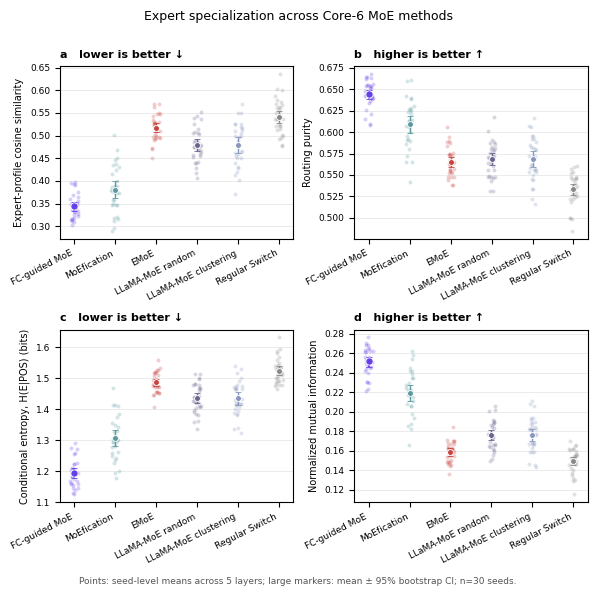

In [20]:
metric_specs = [
    ('cosine_similarity', 'a', 'Expert-profile cosine similarity', 'lower is better ↓'),
    ('routing_purity', 'b', 'Routing purity', 'higher is better ↑'),
    ('conditional_entropy', 'c', 'Conditional entropy, H(E|POS) (bits)', 'lower is better ↓'),
    ('nmi', 'd', 'Normalized mutual information', 'higher is better ↑'),
]
x = np.arange(len(CORE_METHODS))
fig, axes = plt.subplots(2, 2, figsize=(6, 5.6))
rng = np.random.default_rng(20260723)
for ax, (metric, panel, ylabel, direction) in zip(axes.flat, metric_specs):
    for position, method in enumerate(CORE_METHODS):
        values = seed_level.loc[seed_level.method == method, metric].to_numpy(float)
        jitter = rng.uniform(-0.10, 0.10, size=len(values))
        ax.scatter(position + jitter, values, s=8, color=COLORS[method], alpha=0.25, linewidths=0, zorder=2)
        row = summary_metrics[(summary_metrics.method == method) & (summary_metrics.metric == metric)].iloc[0]
        ax.errorbar(
            position, row['mean'],
            yerr=[[row['mean'] - row['ci95_low']], [row['ci95_high'] - row['mean']]],
            fmt='o', markersize=5.2 if method == 'fc_guided' else 4.2,
            color=COLORS[method], markeredgecolor='white', markeredgewidth=0.6,
            capsize=2.3, elinewidth=1.4 if method == 'fc_guided' else 1.0, zorder=4,
        )
    ax.set_xticks(x, [LABELS[m] for m in CORE_METHODS], rotation=27, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{panel}   {direction}', loc='left', fontweight='bold')
    ax.grid(axis='y', color='#E5E5E5', linewidth=0.55, zorder=0)
fig.suptitle('Expert specialization across Core-6 MoE methods', fontsize=9, y=1.01)
fig.text(0.5, -0.015, f'Points: seed-level means across {cfg.n_layers} layers; large markers: mean ± 95% bootstrap CI; n={len(common_seeds)} seeds.', ha='center', fontsize=6.5, color='#555555')
fig.tight_layout(h_pad=1.2, w_pad=1.0)
main_stem = ANALYSIS_DIR / 'expert_specialization_core6_summary'
for suffix in ('png', 'pdf', 'svg'):
    fig.savefig(main_stem.with_suffix('.' + suffix), dpi=300, bbox_inches='tight')
fig.savefig(main_stem.with_suffix('.tiff'), dpi=600, bbox_inches='tight')
plt.show()

## 6. Layer-resolved mechanism figure

Lines show the seed mean and shaded 95% bootstrap CI at each layer. This panel describes where specialization emerges; it is not used to inflate the replicate count.

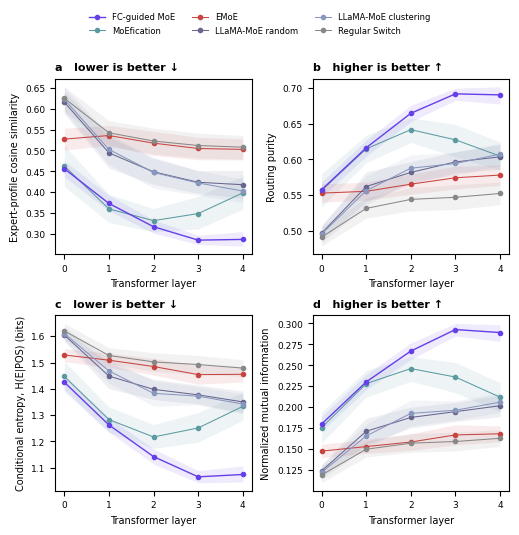

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(5.2, 5.2))
layers = np.arange(cfg.n_layers)
for ax, (metric, panel, ylabel, direction) in zip(axes.flat, metric_specs):
    for method_index, method in enumerate(CORE_METHODS):
        means, lows, highs = [], [], []
        for layer in layers:
            values = raw_df.loc[(raw_df.method == method) & (raw_df.layer == layer), metric]
            mean, low, high = bootstrap_mean_ci(values, seed=20260800 + method_index * 31 + int(layer))
            means.append(mean); lows.append(low); highs.append(high)
        means, lows, highs = map(np.asarray, (means, lows, highs))
        ax.plot(layers, means, color=COLORS[method], label=LABELS[method], linewidth=1 if method == 'fc_guided' else 0.75, marker='o', markersize=3, zorder=5 if method == 'fc_guided' else 4)
        ax.fill_between(layers, lows, highs, color=COLORS[method], alpha=0.10, linewidth=0)
    ax.set_xticks(layers)
    ax.set_xlabel('Transformer layer')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{panel}   {direction}', loc='left', fontweight='bold')
    # ax.grid(color='#E5E5E5', linewidth=0.5)
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=1.1, w_pad=1.0)
layer_stem = ANALYSIS_DIR / 'expert_specialization_core6_by_layer'
for suffix in ('png', 'pdf', 'svg'):
    fig.savefig(layer_stem.with_suffix('.' + suffix), dpi=300, bbox_inches='tight')
fig.savefig(layer_stem.with_suffix('.tiff'), dpi=600, bbox_inches='tight')
plt.show()

## 7. Paired FC comparisons and export manifest

Two-sided paired Wilcoxon tests compare FC-guided MoE with each method using seed as the pairing unit. Holm correction is applied across the five comparisons separately for each metric. `mean_fc_advantage` is signed so positive always favours FC (the sign is reversed for cosine similarity and conditional entropy).

In [9]:
display(paired_stats.sort_values(['metric', 'p_holm_within_metric']).reset_index(drop=True))
manifest = {
    'training_performed': False,
    'checkpoint_count': len(expected_checkpoints),
    'methods': list(CORE_METHODS),
    'seeds': common_seeds,
    'n_layers': cfg.n_layers,
    'n_analyzed_tokens': int(valid_mask.sum()),
    'independent_replicate': 'training seed',
    'within_seed_aggregation': 'arithmetic mean across Transformer layers',
    'confidence_interval': '95% percentile bootstrap across seed-level values, 10,000 resamples',
    'paired_test': 'two-sided Wilcoxon signed-rank; Holm correction within each metric',
    'routing_definition': 'argmax of pre-capacity router probability',
    'excluded_tokens': ['<pad>', '<unk>', '<eos>'],
    'primary_outputs': [
        'expert_specialization_core6_summary.svg/pdf/tiff/png',
        'expert_specialization_core6_by_layer.svg/pdf/tiff/png',
    ],
}
(ANALYSIS_DIR / 'analysis_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print('Analysis complete:', ANALYSIS_DIR.resolve())

,metric,comparison,baseline,n_seeds,mean_raw_difference_fc_minus_baseline,mean_fc_advantage,median_fc_advantage,wilcoxon_statistic,p_value,p_holm_within_metric
0,conditional_entropy,fc_guided vs emoe,emoe,30,-0.292531,0.292531,0.309646,0.0,1.862645e-09,9.313226e-09
1,conditional_entropy,fc_guided vs llama_moe_random,llama_moe_random,30,-0.241804,0.241804,0.238112,0.0,1.862645e-09,9.313226e-09
2,conditional_entropy,fc_guided vs llama_moe_clustering,llama_moe_clustering,30,-0.241206,0.241206,0.242769,0.0,1.862645e-09,9.313226e-09
3,conditional_entropy,fc_guided vs switch_partitioned,switch_partitioned,30,-0.330278,0.330278,0.336283,0.0,1.862645e-09,9.313226e-09
4,conditional_entropy,fc_guided vs moefication,moefication,30,-0.112411,0.112411,0.103092,4.0,1.303852e-08,1.303852e-08
5,cosine_similarity,fc_guided vs emoe,emoe,30,-0.173843,0.173843,0.171564,0.0,1.862645e-09,9.313226e-09
6,cosine_similarity,fc_guided vs llama_moe_random,llama_moe_random,30,-0.136391,0.136391,0.134881,0.0,1.862645e-09,9.313226e-09
7,cosine_similarity,fc_guided vs llama_moe_clustering,llama_moe_clustering,30,-0.135688,0.135688,0.128503,0.0,1.862645e-09,9.313226e-09
8,cosine_similarity,fc_guided vs switch_partitioned,switch_partitioned,30,-0.198162,0.198162,0.199925,0.0,1.862645e-09,9.313226e-09
9,cosine_similarity,fc_guided vs moefication,moefication,30,-0.036661,0.036661,0.031806,82.0,1.340603e-03,1.340603e-03


Analysis complete: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/MoE_benchmark_v2/outputs_formal_fast_core6_v2/analysis_expert_specialization_core6_v2
